# Evaluación 2 — Modelado Predictivo de MRR (SaaSFlow)
Pipeline completo con `Pipeline` + `ColumnTransformer`, sin fuga de datos (*data leakage*).

**Estructura:** Fase 1 EDA → Fase 2 Preprocesamiento → Fase 3 Modelo → Fase 4 Evaluación e insights.

## 0. Librerías y configuración

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Fase 1 — Diagnóstico y calidad de datos (EDA)

In [17]:
RUTA = "https://raw.githubusercontent.com/TheDeliFeli/E2-IA/be5b412213d2951b399f49ab7b4de3fb5e3b8d57/E2-MRR/clientes_mrr_dataset.csv"
df = pd.read_csv(RUTA)

print("Dimensiones:", df.shape)
display(df.head())
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

Dimensiones: (30000, 11)


,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0000,34.3508,7.0000,Mensual,"3,932.3419",Si,706.1600
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.6856,8.0000,Mensual,"2,547.8333",No,555.9500
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0000,50.0270,7.0000,2 Años,"3,203.2327",Si,755.5300
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0000,NaN,9.0000,Anual,603.2093,No,364.9400
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0000,NaN,8.0000,Anual,864.7886,Si,"1,611.9300"



Tipos de datos:


,dtype
id_cliente,object
fecha_registro,object
sector_empresa,object
tamano_empresa,object
tickets_soporte,float64
promedio_sesiones_mes,float64
satisfaccion_nps,float64
duracion_contrato,object
gasto_mkt_asociado,float64
pago_puntual,object


In [18]:
# Porcentaje exacto de nulos por variable
nulos_pct = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
display(nulos_pct.to_frame("% nulos"))

# Duplicados y consistencia de categorías
print("Filas duplicadas:", df.duplicated().sum(), "| IDs duplicados:", df["id_cliente"].duplicated().sum())
for c in ["sector_empresa", "tamano_empresa", "duracion_contrato", "pago_puntual"]:
    print(f"{c}: {df[c].value_counts(dropna=False).to_dict()}")

# Inconsistencia de tipos: fecha_registro llega como texto
print("\nfecha_registro es tipo:", df["fecha_registro"].dtype, "| ejemplo:", df["fecha_registro"].iloc[0])

,% nulos
satisfaccion_nps,11.9900
tickets_soporte,8.2100
promedio_sesiones_mes,5.1500
sector_empresa,0.0000
fecha_registro,0.0000
id_cliente,0.0000
tamano_empresa,0.0000
duracion_contrato,0.0000
gasto_mkt_asociado,0.0000
pago_puntual,0.0000


Filas duplicadas: 0 | IDs duplicados: 0
sector_empresa: {'Tecnologia': 8913, 'Finanzas': 7530, 'Salud': 6018, 'Retail': 4535, 'Educacion': 3004}
tamano_empresa: {'Pequeña': 14884, 'Mediana': 10479, 'Grande': 4637}
duracion_contrato: {'Mensual': 18087, 'Anual': 8895, '2 Años': 3018}
pago_puntual: {'Si': 24088, 'No': 5912}

fecha_registro es tipo: object | ejemplo: 2025-09-14 00:24:49.009633632


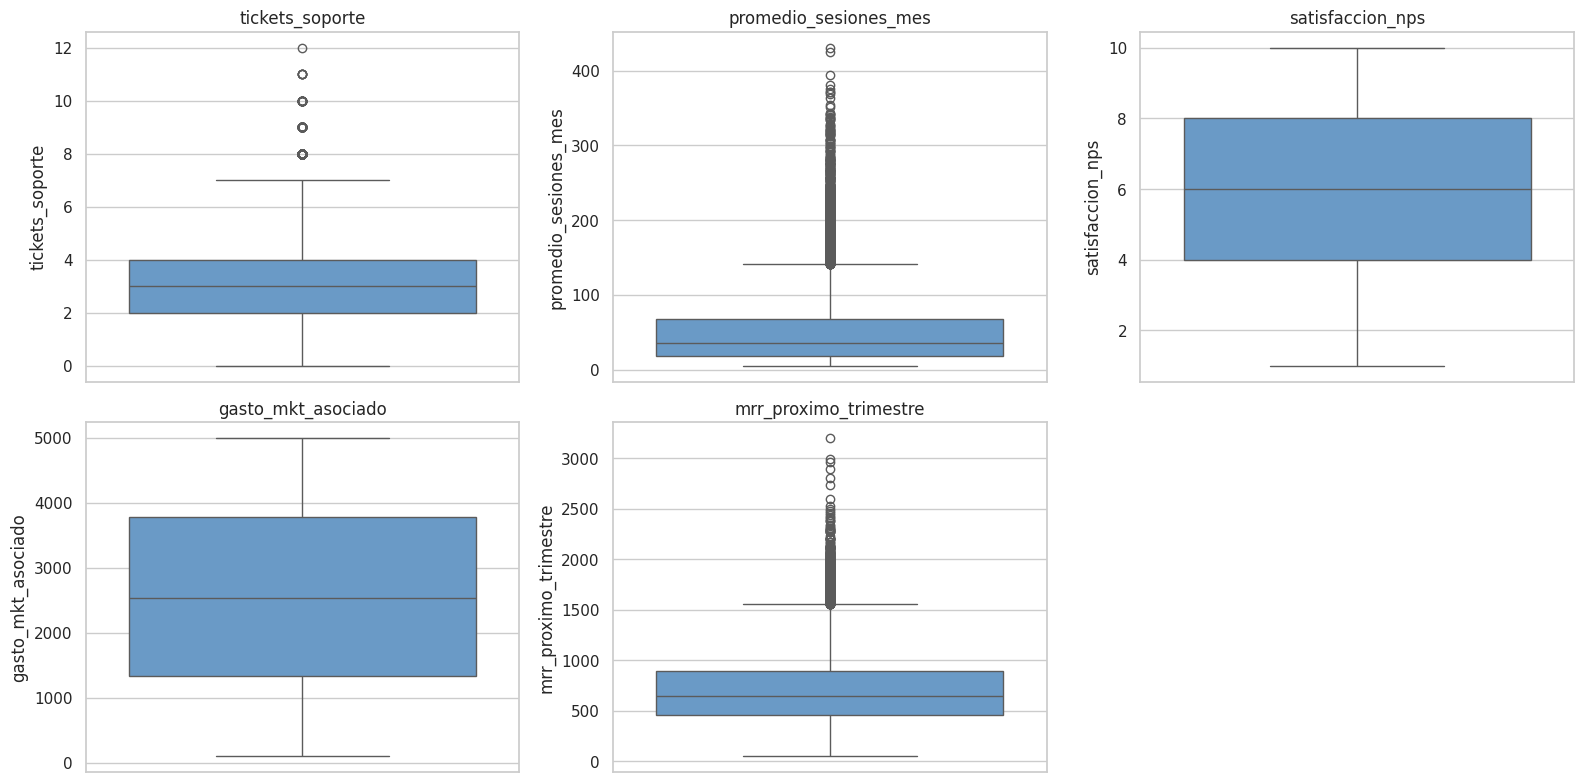

,media,mediana,desv_est,max,sesgo,% outliers IQR
variable,,,,,,
tickets_soporte,3.0051,3.0000,1.7341,12.0000,0.5694,1.1912
promedio_sesiones_mes,50.1306,36.2308,45.0589,430.7014,1.9721,4.8041
satisfaccion_nps,5.9139,6.0000,2.3121,10.0000,-0.4166,0.0000
gasto_mkt_asociado,"2,551.0905","2,541.0739","1,416.1127","4,999.9538",0.0037,0.0000
mrr_proximo_trimestre,710.9263,642.5950,337.6889,"3,200.0400",1.0548,2.0233


In [19]:
# Boxplots para detectar outliers
vars_num = ["tickets_soporte", "promedio_sesiones_mes", "satisfaccion_nps",
            "gasto_mkt_asociado", "mrr_proximo_trimestre"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), vars_num):
    sns.boxplot(y=df[col], ax=ax, color="#5B9BD5")
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

# Medidas de dispersión, sesgo y % de outliers (regla de Tukey 1.5*IQR)
resumen = []
for c in vars_num:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100
    resumen.append({"variable": c, "media": s.mean(), "mediana": s.median(), "desv_est": s.std(),
                    "max": s.max(), "sesgo": s.skew(), "% outliers IQR": out})
display(pd.DataFrame(resumen).set_index("variable"))

**Hallazgos esperados:** nulos en `tickets_soporte`, `promedio_sesiones_mes` y `satisfaccion_nps`; `fecha_registro` como texto; `promedio_sesiones_mes` con fuerte sesgo positivo y outliers extremos; `mrr_proximo_trimestre` con sesgo positivo moderado.

## Fase 2 — Preprocesamiento e ingeniería de características
### 2.1 Transformadores personalizados

In [20]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Limita outliers a los percentiles [lower, upper].
    Los límites se APRENDEN en fit() (solo con train) y se APLICAN en transform()
    a train y test -> sin fuga de datos. Tolera NaN (se imputan después)."""
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_ = np.nanquantile(X, self.upper, axis=0)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)   # NaN se conservan

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


class FeatureEngineering(BaseEstimator, TransformerMixin):
    """Convierte fecha_registro (texto) en antiguedad_dias y elimina
    fecha_registro e id_cliente. La fecha de referencia se fija en fit()
    (máxima fecha de train): así train y test usan el mismo 'hoy'
    y no depende de la fecha en que se ejecute el código."""
    def __init__(self, col_fecha="fecha_registro", cols_drop=("id_cliente",)):
        self.col_fecha = col_fecha
        self.cols_drop = cols_drop

    def fit(self, X, y=None):
        self.fecha_ref_ = pd.to_datetime(X[self.col_fecha]).max()
        return self

    def transform(self, X):
        X = X.copy()
        fechas = pd.to_datetime(X[self.col_fecha])
        X["antiguedad_dias"] = (self.fecha_ref_ - fechas).dt.days.astype(float)
        return X.drop(columns=[self.col_fecha, *self.cols_drop], errors="ignore")

### 2.2 `ColumnTransformer`
- **Numéricas (mediana):** `promedio_sesiones_mes` (muy sesgada → la mediana es robusta), `gasto_mkt_asociado`, `antiguedad_dias`.
- **Numéricas (moda):** `tickets_soporte` y `satisfaccion_nps` son enteros discretos → el valor modal conserva su naturaleza.
- **Ordinal:** `tamano_empresa` (Pequeña < Mediana < Grande).
- **Nominal:** `sector_empresa` con One-Hot (`drop='first'` evita multicolinealidad perfecta).
- **Binarias/ordinales explícitas:** `duracion_contrato` (Mensual=0, Anual=1, 2 Años=2) y `pago_puntual` (No=0, Si=1).

In [21]:
cols_num_mediana = ["promedio_sesiones_mes", "gasto_mkt_asociado", "antiguedad_dias"]
cols_num_moda    = ["tickets_soporte", "satisfaccion_nps"]
col_ord          = ["tamano_empresa"]
col_nom          = ["sector_empresa"]
col_dur          = ["duracion_contrato"]
col_pago         = ["pago_puntual"]

# Winsorizer -> Imputer -> Scaler (orden pedido)
num_mediana = Pipeline([
    ("winsor",  Winsorizer(0.01, 0.99)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
num_moda = Pipeline([
    ("winsor",  Winsorizer(0.01, 0.99)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler",  StandardScaler()),
])
cat_ord = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[["Pequeña", "Mediana", "Grande"]],
                               handle_unknown="use_encoded_value", unknown_value=np.nan)),
])
cat_nom = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
])
bin_dur = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("map",     OrdinalEncoder(categories=[["Mensual", "Anual", "2 Años"]])),
])
bin_pago = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("map",     OrdinalEncoder(categories=[["No", "Si"]])),   # Si = 1
])

preprocesador = ColumnTransformer([
    ("num_mediana", num_mediana, cols_num_mediana),
    ("num_moda",    num_moda,    cols_num_moda),
    ("ord",         cat_ord,     col_ord),
    ("nom",         cat_nom,     col_nom),
    ("dur",         bin_dur,     col_dur),
    ("pago",        bin_pago,    col_pago),
], remainder="drop")

## Fase 3 — Construcción del modelo

In [22]:
X = df.drop(columns="mrr_proximo_trimestre")
y = df["mrr_proximo_trimestre"]

# División 80/20 ANTES de cualquier ajuste -> test queda totalmente "ciego"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

# Pipeline maestro: ingeniería de variables -> preprocesamiento -> regresión
modelo = Pipeline([
    ("feat_eng",      FeatureEngineering()),
    ("preprocesador", preprocesador),
    ("regresion",     LinearRegression()),
])

# fit SOLO con train: límites de winsorización, medianas/modas, medias/desvíos,
# categorías y fecha de referencia se aprenden únicamente de X_train
modelo.fit(X_train, y_train)
print("Modelo entrenado.")

Train: (24000, 10) | Test: (6000, 10)
Modelo entrenado.


## Fase 4 — Evaluación e insights

In [23]:
y_pred_test  = modelo.predict(X_test)
y_pred_train = modelo.predict(X_train)

r2_test  = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train  = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

print("=== CONJUNTO DE PRUEBA ===")
print(f"R²  : {r2_test:.4f}  -> explica {r2_test*100:.1f}% de la varianza del MRR")
print(f"MAE : {mae_test:,.2f} USD por cliente")
print(f"\nMRR promedio real (test): {y_test.mean():,.2f} USD  | error relativo ≈ {mae_test/y_test.mean()*100:.1f}%")
print("\n=== Referencia: TRAIN (chequeo de sobreajuste) ===")
print(f"R² train: {r2_train:.4f} | MAE train: {mae_train:,.2f} USD")

=== CONJUNTO DE PRUEBA ===
R²  : 0.9179  -> explica 91.8% de la varianza del MRR
MAE : 69.29 USD por cliente

MRR promedio real (test): 708.31 USD  | error relativo ≈ 9.8%

=== Referencia: TRAIN (chequeo de sobreajuste) ===
R² train: 0.9140 | MAE train: 70.53 USD


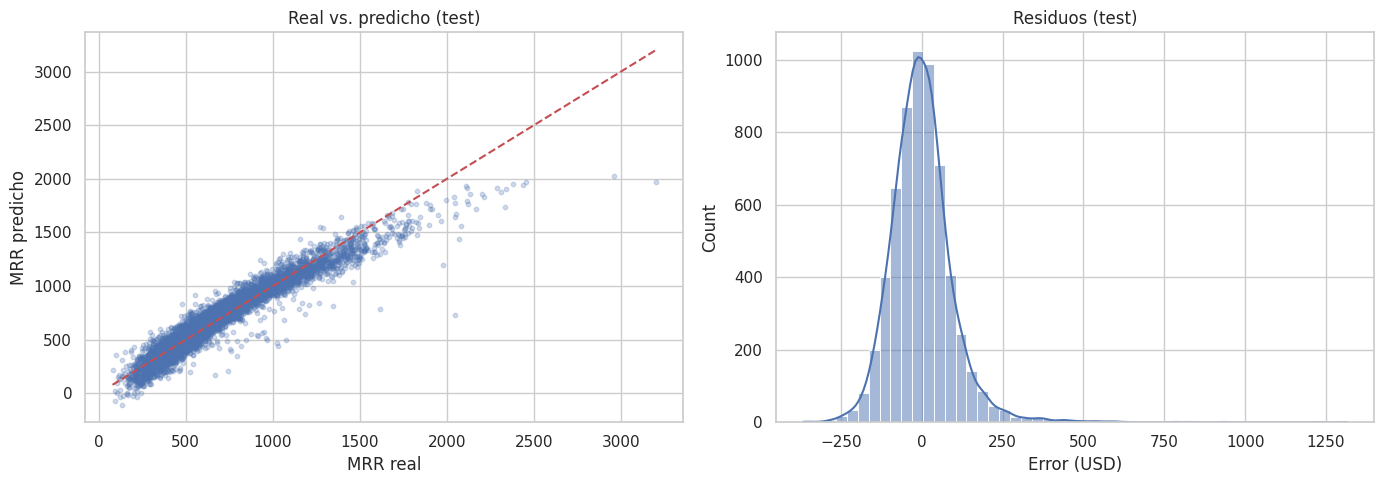

In [24]:
# Real vs. predicho y distribución de residuos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, y_pred_test, alpha=0.25, s=10)
lim = [y_test.min(), y_test.max()]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("MRR real"); ax[0].set_ylabel("MRR predicho")
ax[0].set_title("Real vs. predicho (test)")
sns.histplot(y_test - y_pred_test, bins=50, kde=True, ax=ax[1])
ax[1].set_title("Residuos (test)"); ax[1].set_xlabel("Error (USD)")
plt.tight_layout(); plt.show()

,variable,coeficiente,impacto_abs
0,tamano_empresa,323.4108,323.4108
1,pago_puntual,204.4186,204.4186
2,promedio_sesiones_mes,173.5515,173.5515
3,duracion_contrato,128.4909,128.4909
4,satisfaccion_nps,47.8850,47.8850
5,gasto_mkt_asociado,33.0570,33.0570
6,tickets_soporte,-29.2820,29.2820
7,sector_empresa_Retail,2.6077,2.6077
8,sector_empresa_Finanzas,0.9820,0.9820
9,antiguedad_dias,-0.2595,0.2595


Intercepto: 269.96


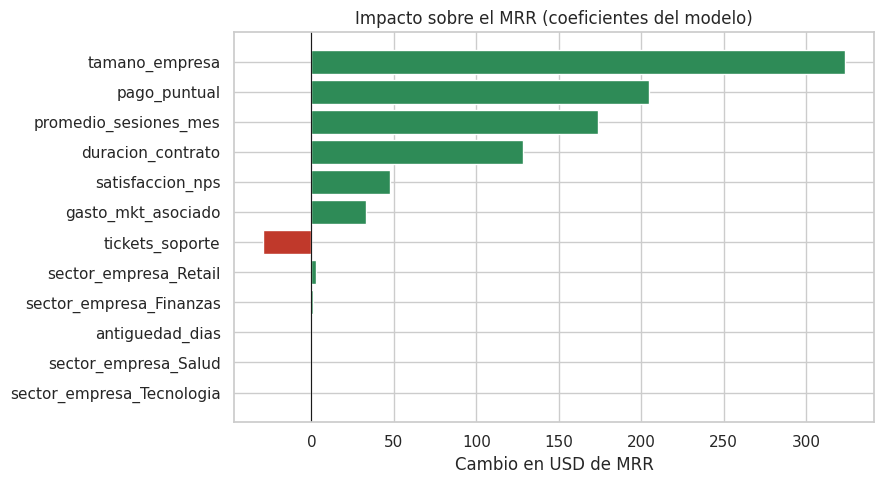

In [25]:
# Coeficientes asociados a los nombres de variables ya transformadas
nombres = modelo.named_steps["preprocesador"].get_feature_names_out()
nombres = [n.split("__", 1)[1] for n in nombres]          # limpia el prefijo del transformador
coefs = modelo.named_steps["regresion"].coef_

ranking = (pd.DataFrame({"variable": nombres, "coeficiente": coefs})
             .assign(impacto_abs=lambda d: d["coeficiente"].abs())
             .sort_values("impacto_abs", ascending=False)
             .reset_index(drop=True))
display(ranking)
print("Intercepto:", round(modelo.named_steps["regresion"].intercept_, 2))

plt.figure(figsize=(9, 5))
colores = ranking["coeficiente"].map(lambda c: "#2E8B57" if c > 0 else "#C0392B")
plt.barh(ranking["variable"][::-1], ranking["coeficiente"][::-1], color=colores[::-1])
plt.axvline(0, color="k", lw=0.8)
plt.title("Impacto sobre el MRR (coeficientes del modelo)")
plt.xlabel("Cambio en USD de MRR")
plt.tight_layout(); plt.show()

### Notas de interpretación
- **Comparabilidad:** las variables continuas están estandarizadas, por lo que su coeficiente = USD de MRR por cada +1 desv. estándar. Las dummies de sector y las binarias están en escala 0/1 (o 0-1-2), por lo que su magnitud no es estrictamente comparable con las escaladas; úsalo como orden de importancia aproximado.
- **Signo:** positivo = más MRR; negativo = menos MRR (riesgo de fuga).
- **R²:** proporción de la varianza del MRR explicada por el modelo. **MAE:** error promedio en USD por cliente.
- **Limitación:** la regresión lineal asume relaciones lineales; si el R² es moderado, probar modelos no lineales (Random Forest, Gradient Boosting) como siguiente paso.